In [36]:
import os
print(os.listdir("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/train"))

['7', '17', '19', '22', '2', '35', '23', '10', '5', '36', '20', '27', '41', '39', '32', '25', '42', '8', '38', '12', '0', '31', '34', '18', '28', '16', '13', '26', '15', '3', '1', '30', '14', '4', '9', '21', '40', '6', '11', '37', '33', '29', '24']


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Dropout,
                                     GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
NUM_CLASSES = 43
EPOCHS      = 50
train_dir   = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/train"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.7, 1.3],
    channel_shift_range=30,
    validation_split=0.2
)
val_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


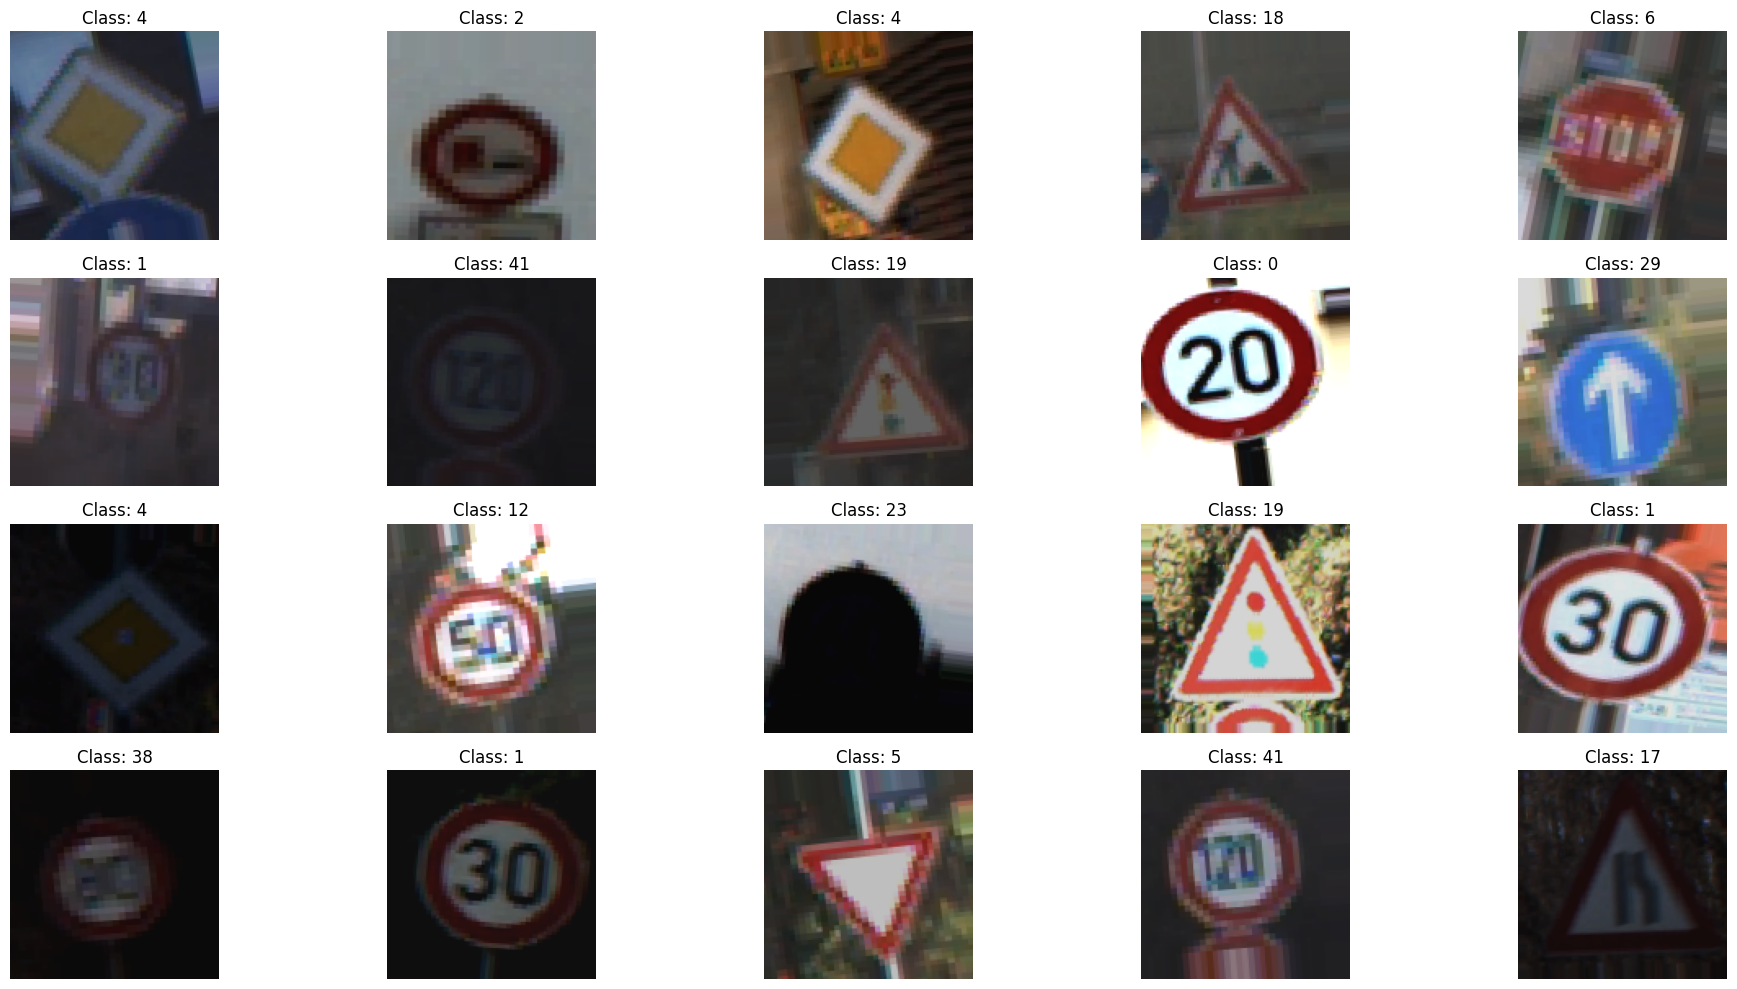

In [44]:
sample_images, sample_labels = next(train_gen)
plt.figure(figsize=(20, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"Class: {np.argmax(sample_labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Callbacks & Helper Functions
early_stop   = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

def train_and_plot(model, name, train_generator=None, val_generator=None, cw=None):
    if train_generator is None:
        train_generator = train_gen
    if val_generator is None:
        val_generator = val_gen
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f"{name}_best.keras",
        save_best_only=True,
        monitor='val_accuracy'
    )
    history = model.fit(
        train_generator, validation_data=val_generator,
        epochs=EPOCHS, callbacks=[early_stop, lr_scheduler, checkpoint],
        class_weight=cw, verbose=1
    )
    epochs_range = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history['loss'], label='Train Loss')
    plt.plot(epochs_range, history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} - Loss'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{name} - Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()
    return history

def evaluate_model(model, name, val_generator=None):
    if val_generator is None:
        val_generator = val_gen
    val_generator.reset()
    preds = model.predict(val_generator)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = val_generator.classes[:len(pred_labels)]
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()
    print(f"\n{name} Classification Report:")
    print(classification_report(true_labels, pred_labels))

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


I0000 00:00:1777764139.838783      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1777764161.405445     157 service.cc:152] XLA service 0x7e32180034c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777764161.405501     157 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777764164.876481     157 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-02 23:22:50.990622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 23:22:51.181865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 23:22:51.482741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

376/981 ━━━━━━━━━━━━━━━━━━━━ 2:57 293ms/step - accuracy: 0.4151 - loss: 2.2499

2026-05-02 23:25:02.116525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 23:25:02.305856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


981/981 ━━━━━━━━━━━━━━━━━━━━ 403s 372ms/step - accuracy: 0.5728 - loss: 1.5658 - val_accuracy: 0.7730 - val_loss: 0.8289 - learning_rate: 5.0000e-04
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 146s 149ms/step - accuracy: 0.8916 - loss: 0.3408 - val_accuracy: 0.8343 - val_loss: 0.5543 - learning_rate: 5.0000e-04
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 146s 148ms/step - accuracy: 0.9284 - loss: 0.2301 - val_accuracy: 0.8374 - val_loss: 0.6355 - learning_rate: 5.0000e-04
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 147s 149ms/step - accuracy: 0.9444 - loss: 0.1822 - val_accuracy: 0.8440 - val_loss: 0.5822 - learning_rate: 5.0000e-04
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 146s 149ms/step - accuracy: 0.9529 - loss: 0.1531 - val_accuracy: 0.8383 - val_loss: 0.6094 - learning_rate: 5.0000e-04
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 147ms/step - accuracy: 0.9586 - loss: 0.1362 - val_accuracy: 0.8496 - val_loss: 0.6091 - learning_rate: 5.0000e-04
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 144s 147ms/

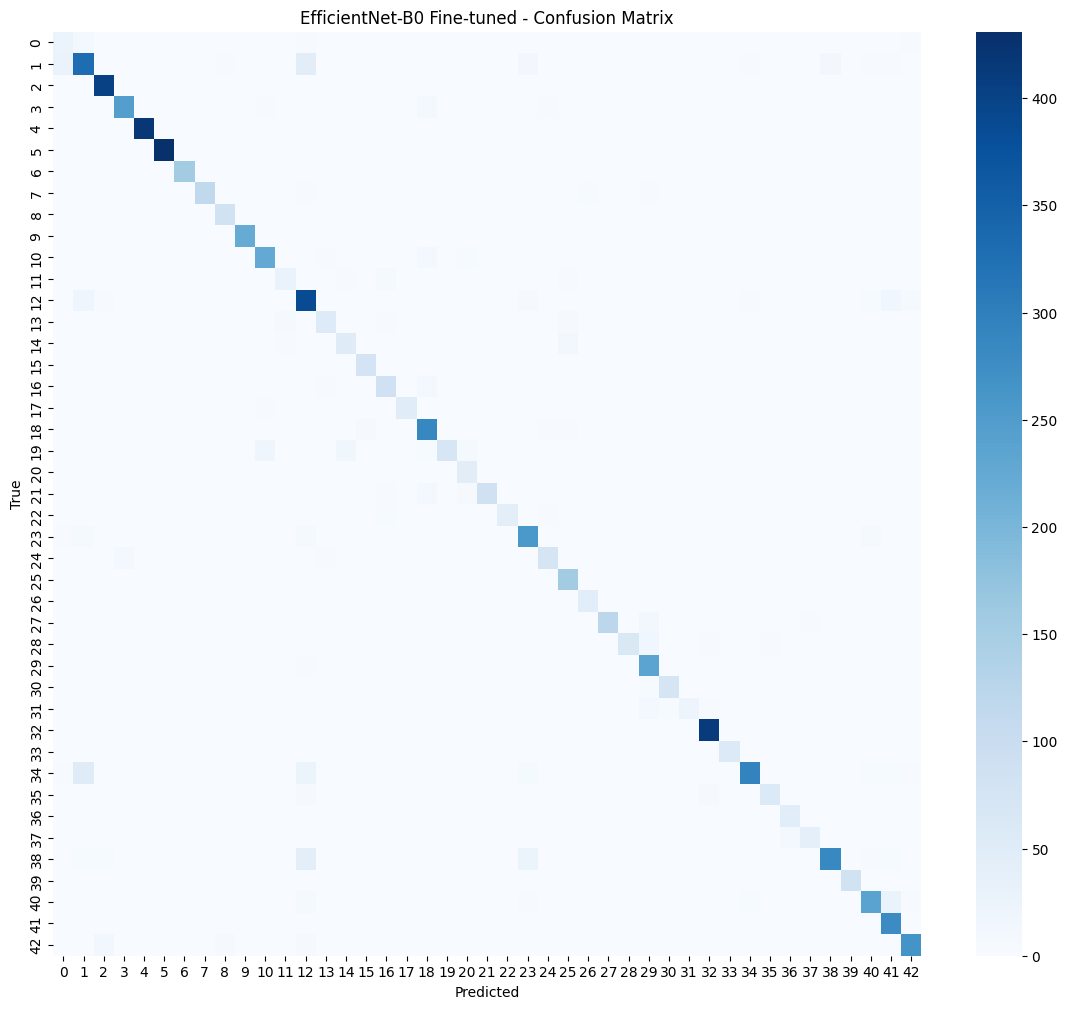


EfficientNet-B0 Fine-tuned Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.62      0.50        42
           1       0.78      0.74      0.76       444
           2       0.94      1.00      0.97       402
           3       0.95      0.94      0.94       264
           4       1.00      1.00      1.00       420
           5       0.99      1.00      1.00       432
           6       1.00      1.00      1.00       156
           7       1.00      0.92      0.96       126
           8       0.90      1.00      0.95        84
           9       1.00      1.00      1.00       222
          10       0.89      0.93      0.91       240
          11       0.72      0.69      0.71        42
          12       0.72      0.86      0.78       450
          13       0.88      0.78      0.82        72
          14       0.68      0.77      0.72        66
          15       0.92      0.99      0.95        78
          16       0.84      0

In [7]:
# Full EfficientNet rebuild + fine-tune in one cell
from tensorflow.keras.applications.efficientnet import preprocess_input

eff_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1,
    validation_split=0.2
)
eff_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)
eff_train_gen = eff_train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)
eff_val_gen = eff_val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_eff.trainable = True
for layer in base_eff.layers[:-60]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_eff.output)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(NUM_CLASSES, activation='softmax')(x)
efficientnet_model = Model(inputs=base_eff.input, outputs=out)

early_stop_new   = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
lr_scheduler_new = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

# Phase 1
efficientnet_model.compile(optimizer=Adam(5e-4), loss='categorical_crossentropy', metrics=['accuracy'])
h3 = efficientnet_model.fit(eff_train_gen, validation_data=eff_val_gen,
                             epochs=15, callbacks=[early_stop_new, lr_scheduler_new], verbose=1)

# Phase 2 — fine-tune
base_eff.trainable = True
for layer in base_eff.layers[:-60]:
    layer.trainable = False
efficientnet_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
h3_finetune = efficientnet_model.fit(eff_train_gen, validation_data=eff_val_gen,
                                      epochs=50, callbacks=[early_stop_new, lr_scheduler_new], verbose=1)

evaluate_model(efficientnet_model, "EfficientNet-B0 Fine-tuned", val_generator=eff_val_gen)